In [1]:
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.data_pipeline import build_dataloaders

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
RAW_DIR = "../data/raw/chest_xray"

loaders = build_dataloaders(
    raw_dir=RAW_DIR,
    batch_size=32,
    val_size=0.15,
    num_workers=2
)

train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 139
Validation batches: 25
Test batches: 20


In [4]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [5]:
class BaselineCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = correct / total

    return loss, accuracy

In [9]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = correct / total

    return loss, accuracy

In [10]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.3332 | Train Acc: 0.8536 | Val Loss: 0.1671 | Val Acc: 0.9350
Epoch 2/10 | Train Loss: 0.2015 | Train Acc: 0.9256 | Val Loss: 0.1380 | Val Acc: 0.9478
Epoch 3/10 | Train Loss: 0.1638 | Train Acc: 0.9413 | Val Loss: 0.2724 | Val Acc: 0.9070
Epoch 4/10 | Train Loss: 0.1546 | Train Acc: 0.9449 | Val Loss: 0.1193 | Val Acc: 0.9554
Epoch 5/10 | Train Loss: 0.1367 | Train Acc: 0.9521 | Val Loss: 0.0990 | Val Acc: 0.9618
Epoch 6/10 | Train Loss: 0.1317 | Train Acc: 0.9548 | Val Loss: 0.1232 | Val Acc: 0.9503
Epoch 7/10 | Train Loss: 0.1172 | Train Acc: 0.9573 | Val Loss: 0.1378 | Val Acc: 0.9490
Epoch 8/10 | Train Loss: 0.1169 | Train Acc: 0.9584 | Val Loss: 0.2035 | Val Acc: 0.9248
Epoch 9/10 | Train Loss: 0.1072 | Train Acc: 0.9602 | Val Loss: 0.1561 | Val Acc: 0.9414
Epoch 10/10 | Train Loss: 0.1109 | Train Acc: 0.9577 | Val Loss: 0.1007 | Val Acc: 0.9541


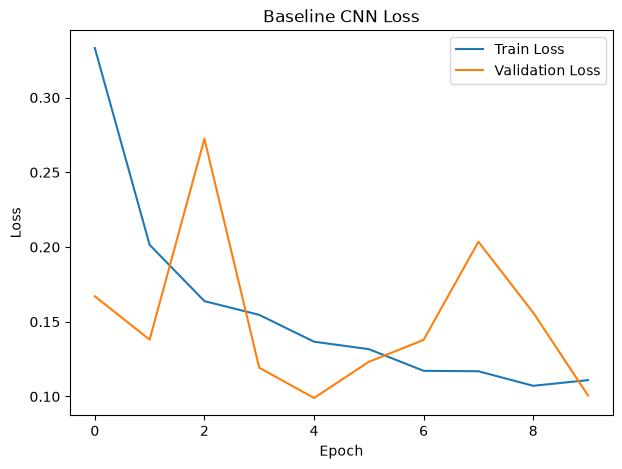

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")

plt.legend()
plt.show()

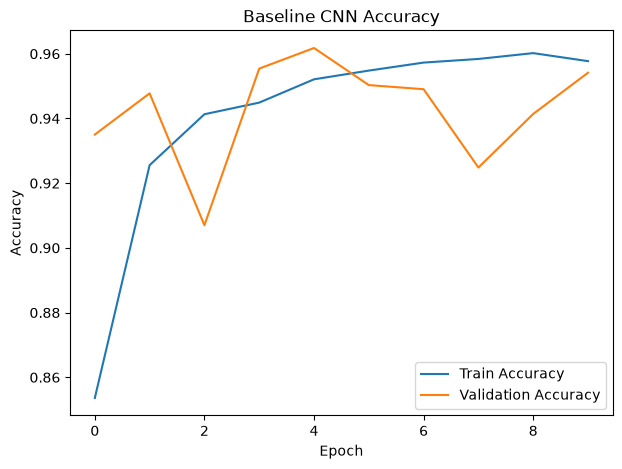

In [12]:
plt.figure(figsize=(7, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")

plt.legend()
plt.show()

In [13]:
Path("../models").mkdir(exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/baseline_cnn.pth"
)

print("Baseline model saved.")

Baseline model saved.
